# 분석 단계별 프로세스 - 순환 신경망 알고리즘

## 1. 라이브러리 / 데이터 불러오기

In [130]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path

DATA_DIR = Path("../data")

df = pd.read_csv(DATA_DIR / "okm_augumented_2021.csv")

## 2. 데이터 종류 및 개수 확인

In [131]:
# 전체 데이터셋 출력
df

# 상위 기본 5개 데이터 확인
df.head()

# head 와 반대로 뒤에서부터 데이터 확인
df.tail()

# 데이터 전체 구조 및 타입 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6165 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6167 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6151 non-null   float64
 17  인건비       6168 non-null   float64
dtypes: float64(6), int64(12)
memory usage: 867.5 KB


## 3. 데이터 정제(전처리)

#### 3-1. 결측치 처리

In [132]:
# 결측치 개수 확인
df.isnull().sum()

# fillna()를 이용해 특정 변수 결측치 값 채우기
# df.fillna({'강수량': 0}, inplace = True)
df.fillna(0, inplace=True)

df_frame = df
df.isnull().sum()

날짜          0
시간          0
15분         0
30분         0
45분         0
60분         0
평균          0
생산량         0
기온          0
풍속          0
습도          0
강수량         0
전기요금(계절)    0
day         0
d           0
m           0
공장인원        0
인건비         0
dtype: int64

#### 3-2. 데이터 특성 파악

<Axes: >

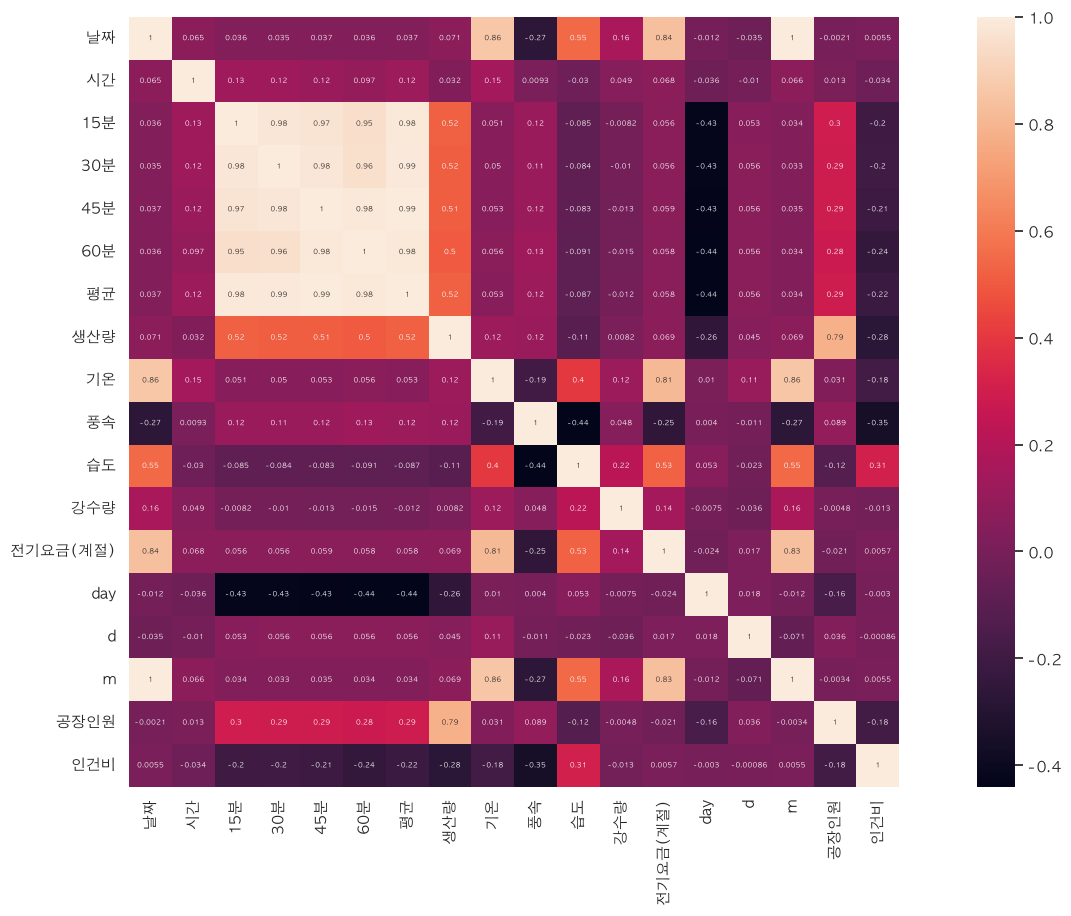

In [133]:
# 요약통계량 확인
df.describe()

# 각 데이터 간 상관관계 확인
df.corr()

plt.rc("font", family="AppleGothic")
sns.set(font="AppleGothic", rc={"axes.unicode_minus": False}, style="darkgrid")
sns.heatmap(df.corr(), vmax=1, square=True, annot=True, annot_kws={"size": 5})

#### 3-3. 데이터 정제

In [134]:
# 사용하지 않는 컬럼 제거
df = df.drop(columns=['생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', 'day', 'd', 'm', '공장인원', '인건비'])
df

# 대상 변수 이름 변경
df = df.rename(columns={"15분": 'Peak Consumption in 15 minute',
                        "30분": 'Peak Consumption in 30 minute',
                        "45분": 'Peak Consumption in 45 minute',
                        "60분": 'Peak Consumption in 60 minute',
                        "평균": 'Average Peak Consumption in 1 hour'})



In [135]:
# index의 날짜 시간대로 변경 
index_column = pd.date_range(start ='2021-01-01 00:00', end ='2021-09-14 23:00', freq ='h')
index_column

df.index =  index_column
df.index.names = ["Date"]
df.head()

,날짜,시간,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour
Date,,,,,,,
2021-01-01 00:00:00,20210101,0,62,61,61,61,61
2021-01-01 01:00:00,20210101,1,96,93,116,113,105
2021-01-01 02:00:00,20210101,2,106,96,106,107,104
2021-01-01 03:00:00,20210101,3,92,110,110,109,105
2021-01-01 04:00:00,20210101,4,108,105,106,108,107


In [136]:
df.index = index_column
df.index.names = ["Date"]
df.head()

,날짜,시간,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour
Date,,,,,,,
2021-01-01 00:00:00,20210101,0,62,61,61,61,61
2021-01-01 01:00:00,20210101,1,96,93,116,113,105
2021-01-01 02:00:00,20210101,2,106,96,106,107,104
2021-01-01 03:00:00,20210101,3,92,110,110,109,105
2021-01-01 04:00:00,20210101,4,108,105,106,108,107


In [137]:
df = df.drop(columns = ["날짜", "시간"])
df

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour
Date,,,,,
2021-01-01 00:00:00,62,61,61,61,61
2021-01-01 01:00:00,96,93,116,113,105
2021-01-01 02:00:00,106,96,106,107,104
2021-01-01 03:00:00,92,110,110,109,105
2021-01-01 04:00:00,108,105,106,108,107
...,...,...,...,...,...
2021-09-14 19:00:00,152,151,171,139,153
2021-09-14 20:00:00,124,130,128,130,128
2021-09-14 21:00:00,134,130,125,124,128


In [138]:
df['Peak Consumption in 15 minute'] = [float(str(val).replace('.','').replace(',','.')) for val in df['Peak Consumption in 15 minute'].values]
df['Peak Consumption in 30 minute'] = [float(str(val).replace('.','').replace(',','.')) for val in df['Peak Consumption in 15 minute'].values]
df['Peak Consumption in 45 minute'] = [float(str(val).replace('.','').replace(',','.')) for val in df['Peak Consumption in 15 minute'].values]
df['Peak Consumption in 60 minute'] = [float(str(val).replace('.','').replace(',','.')) for val in df['Peak Consumption in 15 minute'].values]
df.head()

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour
Date,,,,,
2021-01-01 00:00:00,62.0,620.0,620.0,620.0,61
2021-01-01 01:00:00,96.0,960.0,960.0,960.0,105
2021-01-01 02:00:00,106.0,1060.0,1060.0,1060.0,104
2021-01-01 03:00:00,92.0,920.0,920.0,920.0,105
2021-01-01 04:00:00,108.0,1080.0,1080.0,1080.0,107


#### 3-4. 데이터 시각화 및 파일 저장

In [139]:
sns.set(rc = {'figure.figsize': (20, 10)})

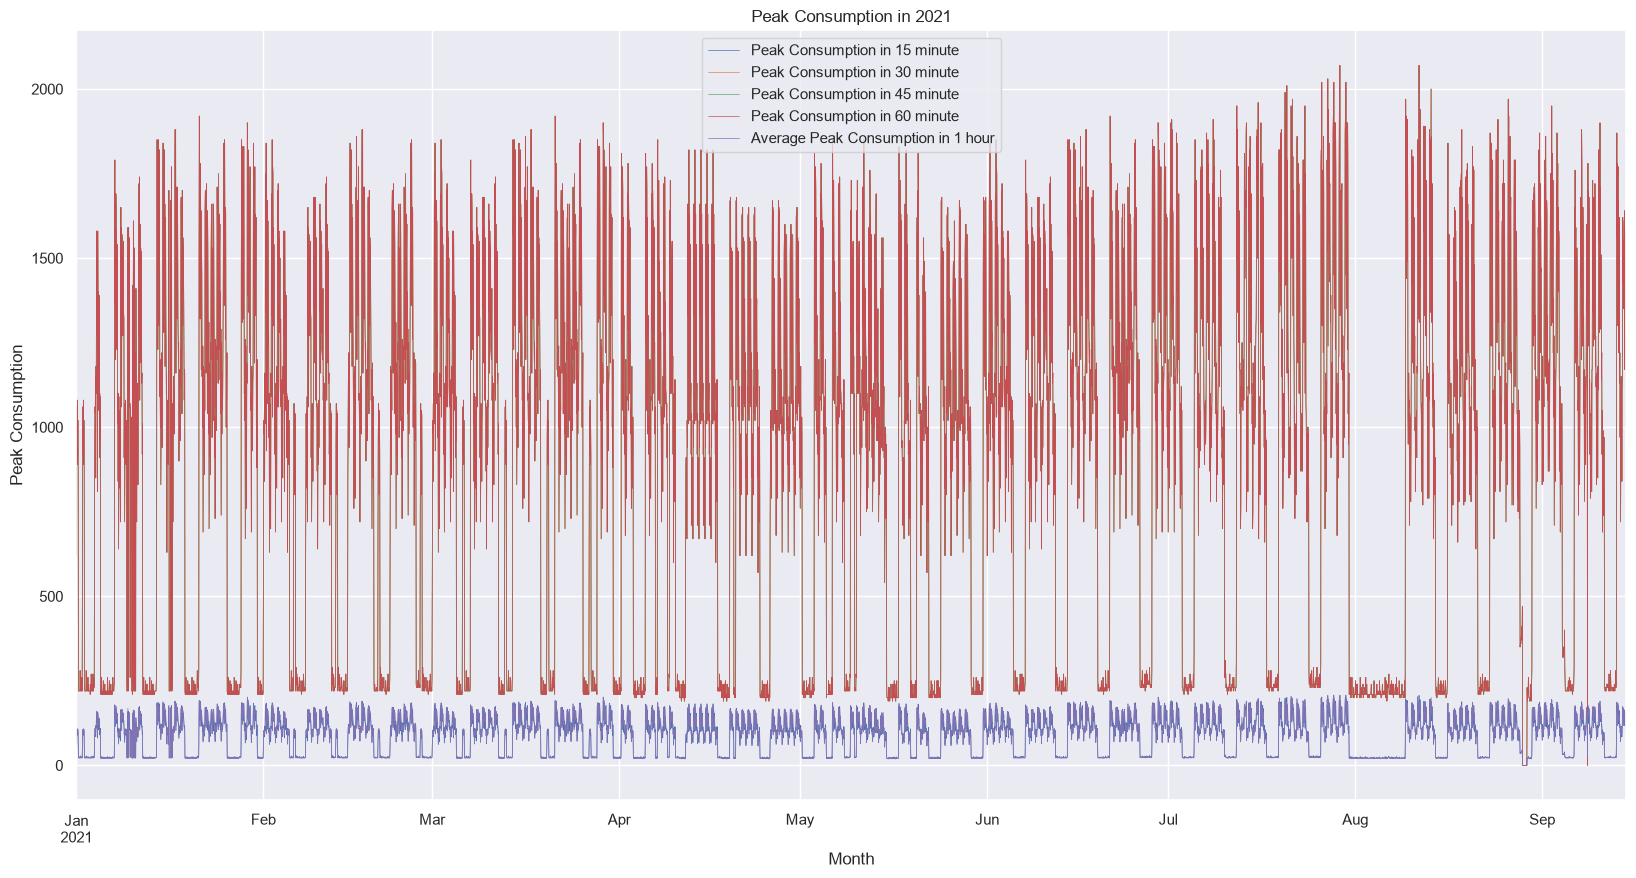

In [140]:
# 2021년도 최대수요전력 값 시각화
df.loc["2021"].plot(linewidth=0.5)

plt.title("Peak Consumption in 2021")
plt.xlabel("Month")
plt.ylabel("Peak Consumption")
plt.show()

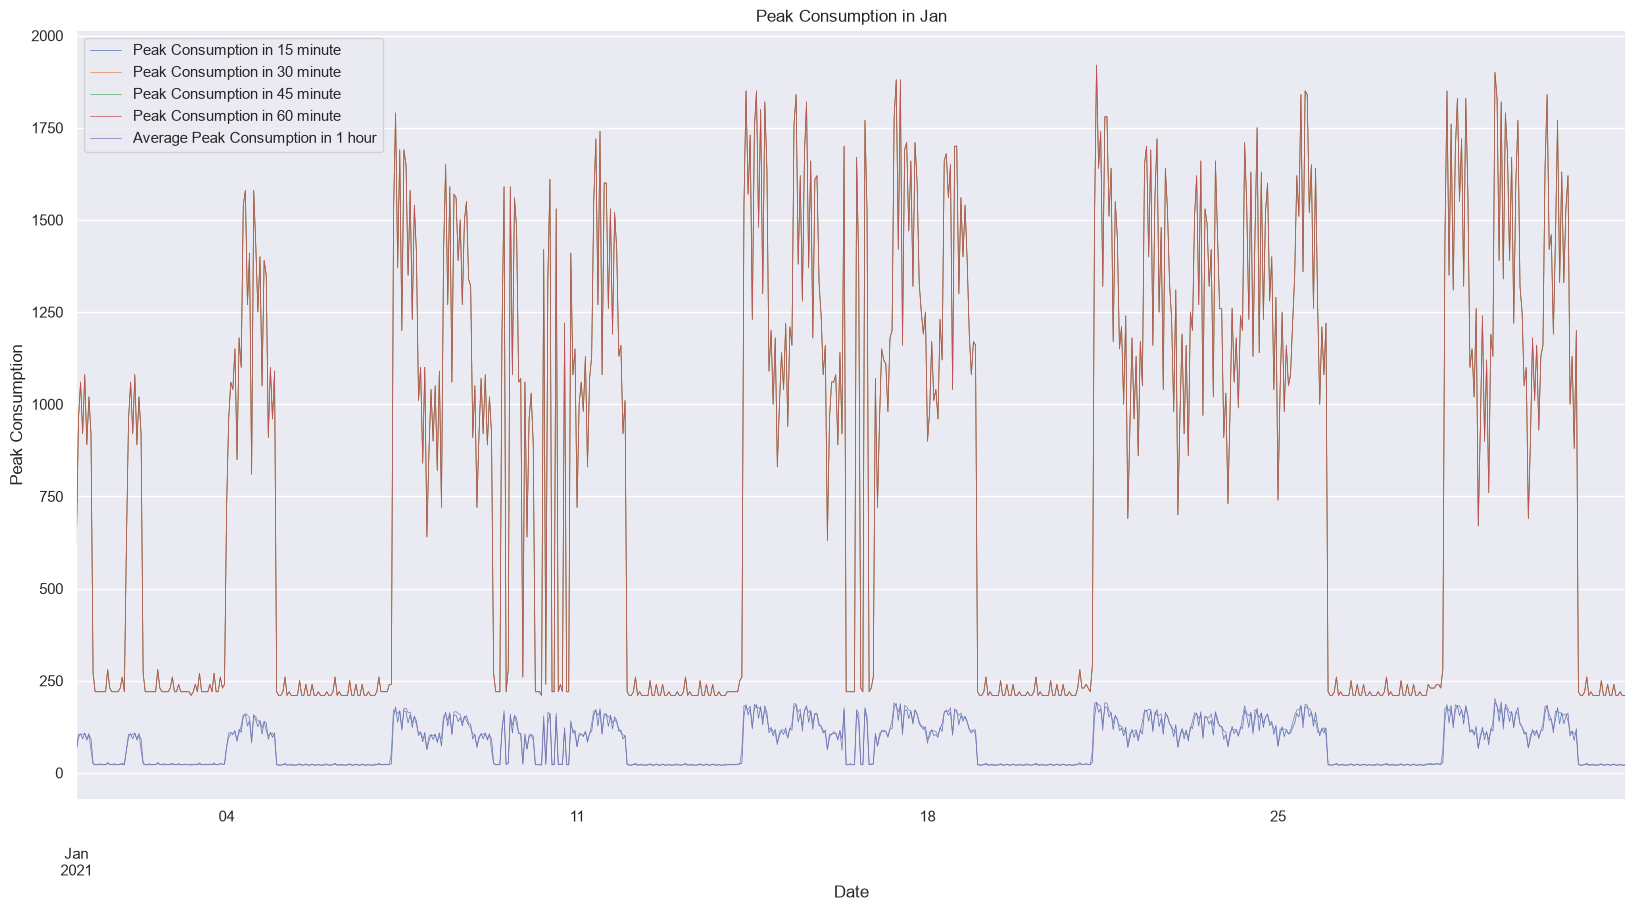

In [141]:
# 2021년도 1월 최대수요전력 값 시각화
df.loc["2021-01"].plot(linewidth = 0.5)

plt.title("Peak Consumption in Jan")
plt.ylabel("Peak Consumption")
plt.show()

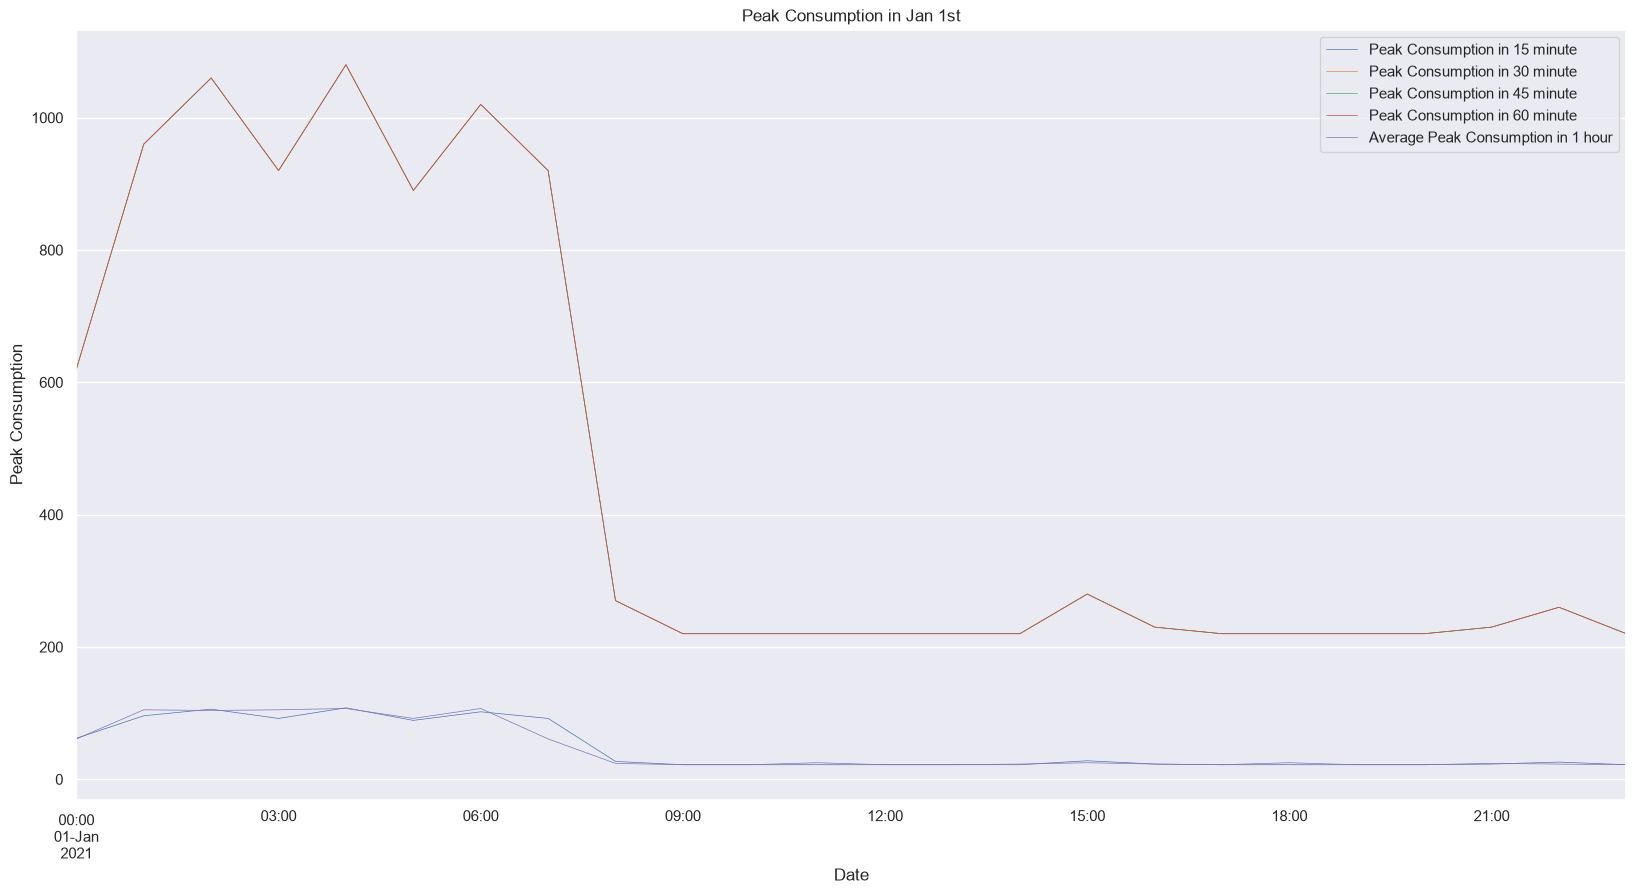

In [142]:
# 2021년도 1월 1일 최대수요전력 값 시각화
df.loc["2021-01-01"].plot(linewidth = 0.5)

plt.title("Peak Consumption in Jan 1st")
plt.ylabel("Peak Consumption")
plt.show()

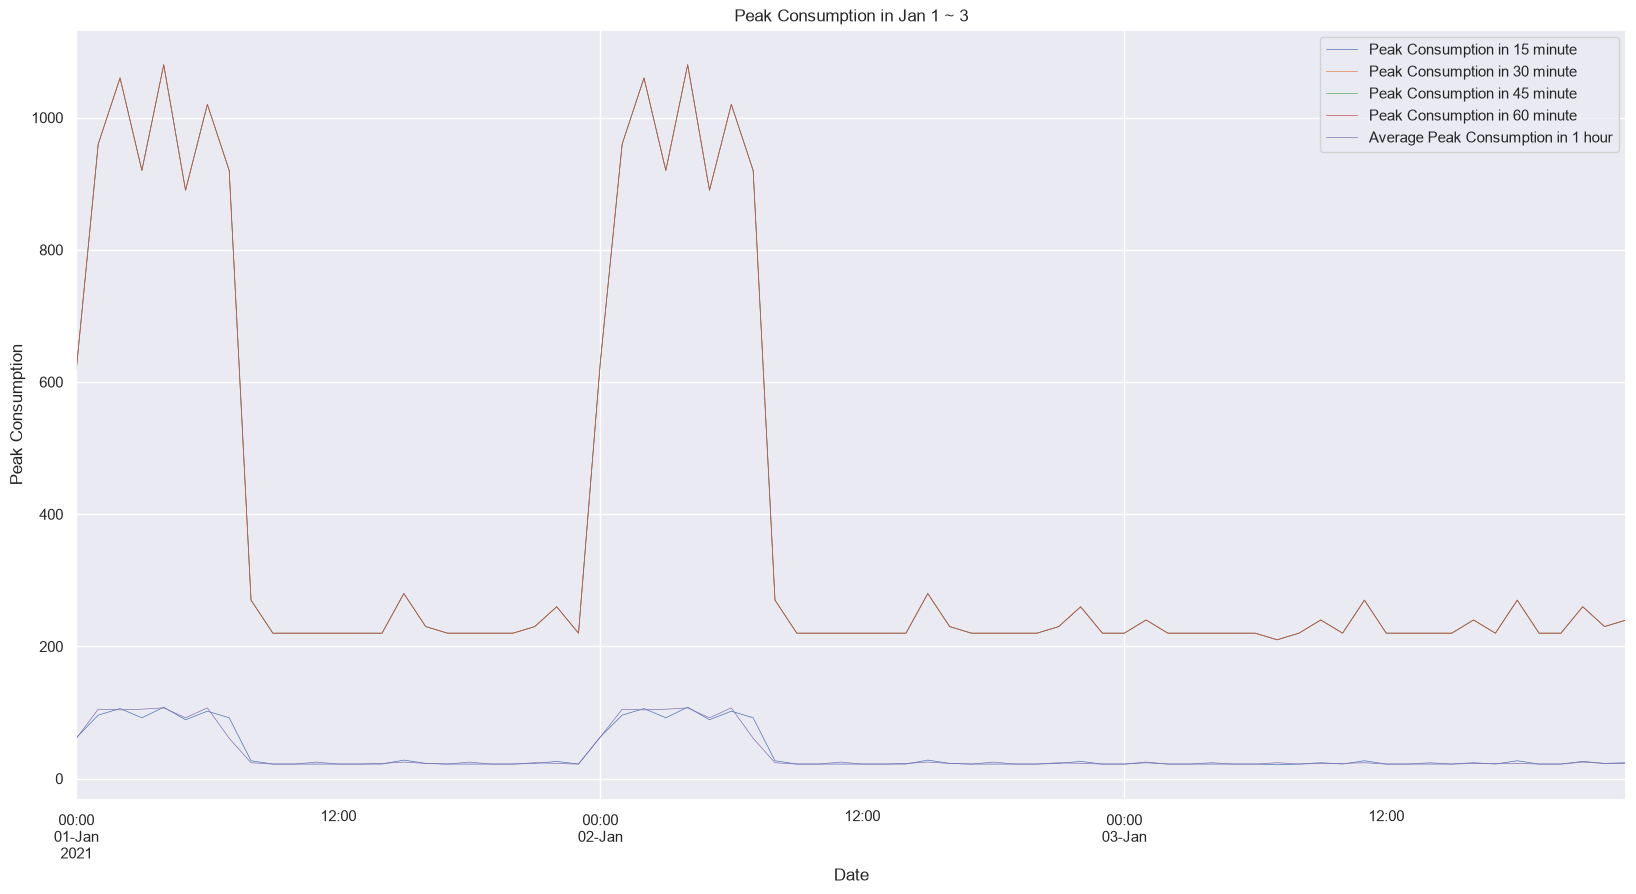

In [143]:
# 2021년도 1월 1일부터 3일까지의 최대수요전력 값 시각화
df.loc["2021-01":"2021-01-03"].plot(linewidth = 0.5)

plt.title("Peak Consumption in Jan 1 ~ 3")
plt.ylabel("Peak Consumption")
plt.show()

#### 3-5. 주말 및 공휴일 데이터 구분

In [144]:
df["Vacation"] = np.zeros(len(df))
df["Weekend"] = np.zeros(len(df))
df.head()

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour,Vacation,Weekend
Date,,,,,,,
2021-01-01 00:00:00,62.0,620.0,620.0,620.0,61,0.0,0.0
2021-01-01 01:00:00,96.0,960.0,960.0,960.0,105,0.0,0.0
2021-01-01 02:00:00,106.0,1060.0,1060.0,1060.0,104,0.0,0.0
2021-01-01 03:00:00,92.0,920.0,920.0,920.0,105,0.0,0.0
2021-01-01 04:00:00,108.0,1080.0,1080.0,1080.0,107,0.0,0.0


In [145]:
# dayofweek를 활용한 요일 값 확인하기
df.loc["2021-01-01"].index.dayofweek

Index([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4], dtype='int32', name='Date')

In [146]:
df.loc[
    (df.index.dayofweek == 5) | (df.index.dayofweek == 6),
    "Weekend"
] = 1

df

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour,Vacation,Weekend
Date,,,,,,,
2021-01-01 00:00:00,62.0,620.0,620.0,620.0,61,0.0,0.0
2021-01-01 01:00:00,96.0,960.0,960.0,960.0,105,0.0,0.0
2021-01-01 02:00:00,106.0,1060.0,1060.0,1060.0,104,0.0,0.0
2021-01-01 03:00:00,92.0,920.0,920.0,920.0,105,0.0,0.0
2021-01-01 04:00:00,108.0,1080.0,1080.0,1080.0,107,0.0,0.0
...,...,...,...,...,...,...,...
2021-09-14 19:00:00,152.0,1520.0,1520.0,1520.0,153,0.0,0.0
2021-09-14 20:00:00,124.0,1240.0,1240.0,1240.0,128,0.0,0.0
2021-09-14 21:00:00,134.0,1340.0,1340.0,1340.0,128,0.0,0.0


In [147]:
# 공휴일 변수 선언하기
holidays = ["2021-01-01", "2021-02-11", "2021-02-12","2021-03-01", "2021-05-05", "2021-05-19", "2021-08-16"]

In [148]:
# 반복문 활용해서 값 부여하기
for gun,j in df.iterrows():
    if str(gun)[:10] in holidays:
        df.loc[gun, "Vacation"] =1

df.head(5)

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour,Vacation,Weekend
Date,,,,,,,
2021-01-01 00:00:00,62.0,620.0,620.0,620.0,61,1.0,0.0
2021-01-01 01:00:00,96.0,960.0,960.0,960.0,105,1.0,0.0
2021-01-01 02:00:00,106.0,1060.0,1060.0,1060.0,104,1.0,0.0
2021-01-01 03:00:00,92.0,920.0,920.0,920.0,105,1.0,0.0
2021-01-01 04:00:00,108.0,1080.0,1080.0,1080.0,107,1.0,0.0


In [149]:
# csv 파일 저장하기
df.to_csv("../results/daily_data_seasonality.csv", index=True)

#### 3-6. Window Features 생성
- window란 : 시간 단위
- 일주일 24시간 이므로 7*24 = 168

In [150]:
# 파일 불러오기
daily_data = pd.read_csv(
    "../results/daily_data_seasonality.csv",
    header=0,
    index_col=0,
    parse_dates=True
)

In [151]:
daily_data =daily_data[["Peak Consumption in 15 minute"]]
daily_data

,Peak Consumption in 15 minute
Date,
2021-01-01 00:00:00,62.0
2021-01-01 01:00:00,96.0
2021-01-01 02:00:00,106.0
2021-01-01 03:00:00,92.0
2021-01-01 04:00:00,108.0
...,...
2021-09-14 19:00:00,152.0
2021-09-14 20:00:00,124.0
2021-09-14 21:00:00,134.0


In [152]:
n_times_advance = 1
n_times_windows =168

In [153]:
for k in range(n_times_advance, n_times_advance + n_times_windows):
    daily_data["Peak Consumption in 15 minute_t-%i" % k] = np.zeros(
        len(daily_data["Peak Consumption in 15 minute"])
    )

daily_data

/var/folders/vf/znfb070j6k715nvznr4dfvn80000gn/T/ipykernel_14993/582114654.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  daily_data["Peak Consumption in 15 minute_t-%i" % k] = np.zeros(


,Peak Consumption in 15 minute,Peak Consumption in 15 minute_t-1,Peak Consumption in 15 minute_t-2,Peak Consumption in 15 minute_t-3,Peak Consumption in 15 minute_t-4,Peak Consumption in 15 minute_t-5,Peak Consumption in 15 minute_t-6,Peak Consumption in 15 minute_t-7,Peak Consumption in 15 minute_t-8,Peak Consumption in 15 minute_t-9,Peak Consumption in 15 minute_t-10,Peak Consumption in 15 minute_t-11,Peak Consumption in 15 minute_t-12,Peak Consumption in 15 minute_t-13,Peak Consumption in 15 minute_t-14,Peak Consumption in 15 minute_t-15,Peak Consumption in 15 minute_t-16,Peak Consumption in 15 minute_t-17,Peak Consumption in 15 minute_t-18,Peak Consumption in 15 minute_t-19,Peak Consumption in 15 minute_t-20,Peak Consumption in 15 minute_t-21,Peak Consumption in 15 minute_t-22,Peak Consumption in 15 minute_t-23,Peak Consumption in 15 minute_t-24,Peak Consumption in 15 minute_t-25,Peak Consumption in 15 minute_t-26,Peak Consumption in 15 minute_t-27,Peak Consumption in 15 minute_t-28,Peak Consumption in 15 minute_t-29,Peak Consumption in 15 minute_t-30,Peak Consumption in 15 minute_t-31,Peak Consumption in 15 minute_t-32,Peak Consumption in 15 minute_t-33,Peak Consumption in 15 minute_t-34,Peak Consumption in 15 minute_t-35,Peak Consumption in 15 minute_t-36,Peak Consumption in 15 minute_t-37,Peak Consumption in 15 minute_t-38,Peak Consumption in 15 minute_t-39,...,Peak Consumption in 15 minute_t-129,Peak Consumption in 15 minute_t-130,Peak Consumption in 15 minute_t-131,Peak Consumption in 15 minute_t-132,Peak Consumption in 15 minute_t-133,Peak Consumption in 15 minute_t-134,Peak Consumption in 15 minute_t-135,Peak Consumption in 15 minute_t-136,Peak Consumption in 15 minute_t-137,Peak Consumption in 15 minute_t-138,Peak Consumption in 15 minute_t-139,Peak Consumption in 15 minute_t-140,Peak Consumption in 15 minute_t-141,Peak Consumption in 15 minute_t-142,Peak Consumption in 15 minute_t-143,Peak Consumption in 15 minute_t-144,Peak Consumption in 15 minute_t-145,Peak Consumption in 15 minute_t-146,Peak Consumption in 15 minute_t-147,Peak Consumption in 15 minute_t-148,Peak Consumption in 15 minute_t-149,Peak Consumption in 15 minute_t-150,Peak Consumption in 15 minute_t-151,Peak Consumption in 15 minute_t-152,Peak Consumption in 15 minute_t-153,Peak Consumption in 15 minute_t-154,Peak Consumption in 15 minute_t-155,Peak Consumption in 15 minute_t-156,Peak Consumption in 15 minute_t-157,Peak Consumption in 15 minute_t-158,Peak Consumption in 15 minute_t-159,Peak Consumption in 15 minute_t-160,Peak Consumption in 15 minute_t-161,Peak Consumption in 15 minute_t-162,Peak Consumption in 15 minute_t-163,Peak Consumption in 15 minute_t-164,Peak Consumption in 15 minute_t-165,Peak Consumption in 15 minute_t-166,Peak Consumption in 15 minute_t-167,Peak Consumption in 15 minute_t-168
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,62.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 01:00:00,96.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 02:00:00,106.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 03:00:00,92.0,0.0,0.0,0.0,0.0,0.0,0.

In [ ]:
target_col = "Peak Consumption in 15 minute"

for i in range(
    n_times_advance + n_times_windows,
    len(daily_data)
):
    for j in range(
        n_times_advance,
        n_times_advance + n_times_windows
    ):
        lag_col = f"Peak Consumption in 15 minute_t-{j}"

        daily_data.iloc[
            i,
            daily_data.columns.get_loc(lag_col)
        ] = daily_data.iloc[
            i - j,
            daily_data.columns.get_loc(target_col)
        ]

In [ ]:
daily_data.to_csv("../results/daily_data_seasonality_168.csv", index = True)
daily_data.head(3)

,Peak Consumption in 15 minute,Peak Consumption in 15 minute_t-1,Peak Consumption in 15 minute_t-2,Peak Consumption in 15 minute_t-3,Peak Consumption in 15 minute_t-4,Peak Consumption in 15 minute_t-5,Peak Consumption in 15 minute_t-6,Peak Consumption in 15 minute_t-7,Peak Consumption in 15 minute_t-8,Peak Consumption in 15 minute_t-9,Peak Consumption in 15 minute_t-10,Peak Consumption in 15 minute_t-11,Peak Consumption in 15 minute_t-12,Peak Consumption in 15 minute_t-13,Peak Consumption in 15 minute_t-14,Peak Consumption in 15 minute_t-15,Peak Consumption in 15 minute_t-16,Peak Consumption in 15 minute_t-17,Peak Consumption in 15 minute_t-18,Peak Consumption in 15 minute_t-19,Peak Consumption in 15 minute_t-20,Peak Consumption in 15 minute_t-21,Peak Consumption in 15 minute_t-22,Peak Consumption in 15 minute_t-23,Peak Consumption in 15 minute_t-24,Peak Consumption in 15 minute_t-25,Peak Consumption in 15 minute_t-26,Peak Consumption in 15 minute_t-27,Peak Consumption in 15 minute_t-28,Peak Consumption in 15 minute_t-29,Peak Consumption in 15 minute_t-30,Peak Consumption in 15 minute_t-31,Peak Consumption in 15 minute_t-32,Peak Consumption in 15 minute_t-33,Peak Consumption in 15 minute_t-34,Peak Consumption in 15 minute_t-35,Peak Consumption in 15 minute_t-36,Peak Consumption in 15 minute_t-37,Peak Consumption in 15 minute_t-38,Peak Consumption in 15 minute_t-39,...,Peak Consumption in 15 minute_t-129,Peak Consumption in 15 minute_t-130,Peak Consumption in 15 minute_t-131,Peak Consumption in 15 minute_t-132,Peak Consumption in 15 minute_t-133,Peak Consumption in 15 minute_t-134,Peak Consumption in 15 minute_t-135,Peak Consumption in 15 minute_t-136,Peak Consumption in 15 minute_t-137,Peak Consumption in 15 minute_t-138,Peak Consumption in 15 minute_t-139,Peak Consumption in 15 minute_t-140,Peak Consumption in 15 minute_t-141,Peak Consumption in 15 minute_t-142,Peak Consumption in 15 minute_t-143,Peak Consumption in 15 minute_t-144,Peak Consumption in 15 minute_t-145,Peak Consumption in 15 minute_t-146,Peak Consumption in 15 minute_t-147,Peak Consumption in 15 minute_t-148,Peak Consumption in 15 minute_t-149,Peak Consumption in 15 minute_t-150,Peak Consumption in 15 minute_t-151,Peak Consumption in 15 minute_t-152,Peak Consumption in 15 minute_t-153,Peak Consumption in 15 minute_t-154,Peak Consumption in 15 minute_t-155,Peak Consumption in 15 minute_t-156,Peak Consumption in 15 minute_t-157,Peak Consumption in 15 minute_t-158,Peak Consumption in 15 minute_t-159,Peak Consumption in 15 minute_t-160,Peak Consumption in 15 minute_t-161,Peak Consumption in 15 minute_t-162,Peak Consumption in 15 minute_t-163,Peak Consumption in 15 minute_t-164,Peak Consumption in 15 minute_t-165,Peak Consumption in 15 minute_t-166,Peak Consumption in 15 minute_t-167,Peak Consumption in 15 minute_t-168
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,62.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 01:00:00,96.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 02:00:00,106.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
target_col = "Peak Consumption in 15 minute"

for j in range(1, 169):
    lag_col = f"Peak Consumption in 15 minute_t-{j}"

    expected = daily_data[target_col].shift(j)

    actual = daily_data[lag_col]

    start = n_times_advance + n_times_windows

    assert actual.iloc[start:].equals(
        expected.iloc[start:]
    ), f"t-{j} 결과 불일치"

print("모든 lag feature 결과 일치")

모든 lag feature 결과 일치


## 4. 훈련/테스트 데이터 분리

In [ ]:
# 패키지 불러오기
import math
from sklearn.model_selection import train_test_split


In [ ]:
daily_data_168 = pd.read_csv('../results/daily_data_seasonality_168.csv',
                header=0, index_col=0, parse_dates=True)
daily_data_168.head()

,Peak Consumption in 15 minute,Peak Consumption in 15 minute_t-1,Peak Consumption in 15 minute_t-2,Peak Consumption in 15 minute_t-3,Peak Consumption in 15 minute_t-4,Peak Consumption in 15 minute_t-5,Peak Consumption in 15 minute_t-6,Peak Consumption in 15 minute_t-7,Peak Consumption in 15 minute_t-8,Peak Consumption in 15 minute_t-9,Peak Consumption in 15 minute_t-10,Peak Consumption in 15 minute_t-11,Peak Consumption in 15 minute_t-12,Peak Consumption in 15 minute_t-13,Peak Consumption in 15 minute_t-14,Peak Consumption in 15 minute_t-15,Peak Consumption in 15 minute_t-16,Peak Consumption in 15 minute_t-17,Peak Consumption in 15 minute_t-18,Peak Consumption in 15 minute_t-19,Peak Consumption in 15 minute_t-20,Peak Consumption in 15 minute_t-21,Peak Consumption in 15 minute_t-22,Peak Consumption in 15 minute_t-23,Peak Consumption in 15 minute_t-24,Peak Consumption in 15 minute_t-25,Peak Consumption in 15 minute_t-26,Peak Consumption in 15 minute_t-27,Peak Consumption in 15 minute_t-28,Peak Consumption in 15 minute_t-29,Peak Consumption in 15 minute_t-30,Peak Consumption in 15 minute_t-31,Peak Consumption in 15 minute_t-32,Peak Consumption in 15 minute_t-33,Peak Consumption in 15 minute_t-34,Peak Consumption in 15 minute_t-35,Peak Consumption in 15 minute_t-36,Peak Consumption in 15 minute_t-37,Peak Consumption in 15 minute_t-38,Peak Consumption in 15 minute_t-39,...,Peak Consumption in 15 minute_t-129,Peak Consumption in 15 minute_t-130,Peak Consumption in 15 minute_t-131,Peak Consumption in 15 minute_t-132,Peak Consumption in 15 minute_t-133,Peak Consumption in 15 minute_t-134,Peak Consumption in 15 minute_t-135,Peak Consumption in 15 minute_t-136,Peak Consumption in 15 minute_t-137,Peak Consumption in 15 minute_t-138,Peak Consumption in 15 minute_t-139,Peak Consumption in 15 minute_t-140,Peak Consumption in 15 minute_t-141,Peak Consumption in 15 minute_t-142,Peak Consumption in 15 minute_t-143,Peak Consumption in 15 minute_t-144,Peak Consumption in 15 minute_t-145,Peak Consumption in 15 minute_t-146,Peak Consumption in 15 minute_t-147,Peak Consumption in 15 minute_t-148,Peak Consumption in 15 minute_t-149,Peak Consumption in 15 minute_t-150,Peak Consumption in 15 minute_t-151,Peak Consumption in 15 minute_t-152,Peak Consumption in 15 minute_t-153,Peak Consumption in 15 minute_t-154,Peak Consumption in 15 minute_t-155,Peak Consumption in 15 minute_t-156,Peak Consumption in 15 minute_t-157,Peak Consumption in 15 minute_t-158,Peak Consumption in 15 minute_t-159,Peak Consumption in 15 minute_t-160,Peak Consumption in 15 minute_t-161,Peak Consumption in 15 minute_t-162,Peak Consumption in 15 minute_t-163,Peak Consumption in 15 minute_t-164,Peak Consumption in 15 minute_t-165,Peak Consumption in 15 minute_t-166,Peak Consumption in 15 minute_t-167,Peak Consumption in 15 minute_t-168
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,62.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 01:00:00,96.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 02:00:00,106.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 03:00:00,92.0,0.0,0.0,0.0,0.0,0.0,0.

In [ ]:
length_train_168=len(daily_data_168)-336

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_168 = MinMaxScaler(feature_range=(0,1))
scaler_168

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [ ]:
daily_data_sc_168 =scaler_168.fit_transform(daily_data_168)
daily_data_168

,Peak Consumption in 15 minute,Peak Consumption in 15 minute_t-1,Peak Consumption in 15 minute_t-2,Peak Consumption in 15 minute_t-3,Peak Consumption in 15 minute_t-4,Peak Consumption in 15 minute_t-5,Peak Consumption in 15 minute_t-6,Peak Consumption in 15 minute_t-7,Peak Consumption in 15 minute_t-8,Peak Consumption in 15 minute_t-9,Peak Consumption in 15 minute_t-10,Peak Consumption in 15 minute_t-11,Peak Consumption in 15 minute_t-12,Peak Consumption in 15 minute_t-13,Peak Consumption in 15 minute_t-14,Peak Consumption in 15 minute_t-15,Peak Consumption in 15 minute_t-16,Peak Consumption in 15 minute_t-17,Peak Consumption in 15 minute_t-18,Peak Consumption in 15 minute_t-19,Peak Consumption in 15 minute_t-20,Peak Consumption in 15 minute_t-21,Peak Consumption in 15 minute_t-22,Peak Consumption in 15 minute_t-23,Peak Consumption in 15 minute_t-24,Peak Consumption in 15 minute_t-25,Peak Consumption in 15 minute_t-26,Peak Consumption in 15 minute_t-27,Peak Consumption in 15 minute_t-28,Peak Consumption in 15 minute_t-29,Peak Consumption in 15 minute_t-30,Peak Consumption in 15 minute_t-31,Peak Consumption in 15 minute_t-32,Peak Consumption in 15 minute_t-33,Peak Consumption in 15 minute_t-34,Peak Consumption in 15 minute_t-35,Peak Consumption in 15 minute_t-36,Peak Consumption in 15 minute_t-37,Peak Consumption in 15 minute_t-38,Peak Consumption in 15 minute_t-39,...,Peak Consumption in 15 minute_t-129,Peak Consumption in 15 minute_t-130,Peak Consumption in 15 minute_t-131,Peak Consumption in 15 minute_t-132,Peak Consumption in 15 minute_t-133,Peak Consumption in 15 minute_t-134,Peak Consumption in 15 minute_t-135,Peak Consumption in 15 minute_t-136,Peak Consumption in 15 minute_t-137,Peak Consumption in 15 minute_t-138,Peak Consumption in 15 minute_t-139,Peak Consumption in 15 minute_t-140,Peak Consumption in 15 minute_t-141,Peak Consumption in 15 minute_t-142,Peak Consumption in 15 minute_t-143,Peak Consumption in 15 minute_t-144,Peak Consumption in 15 minute_t-145,Peak Consumption in 15 minute_t-146,Peak Consumption in 15 minute_t-147,Peak Consumption in 15 minute_t-148,Peak Consumption in 15 minute_t-149,Peak Consumption in 15 minute_t-150,Peak Consumption in 15 minute_t-151,Peak Consumption in 15 minute_t-152,Peak Consumption in 15 minute_t-153,Peak Consumption in 15 minute_t-154,Peak Consumption in 15 minute_t-155,Peak Consumption in 15 minute_t-156,Peak Consumption in 15 minute_t-157,Peak Consumption in 15 minute_t-158,Peak Consumption in 15 minute_t-159,Peak Consumption in 15 minute_t-160,Peak Consumption in 15 minute_t-161,Peak Consumption in 15 minute_t-162,Peak Consumption in 15 minute_t-163,Peak Consumption in 15 minute_t-164,Peak Consumption in 15 minute_t-165,Peak Consumption in 15 minute_t-166,Peak Consumption in 15 minute_t-167,Peak Consumption in 15 minute_t-168
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,62.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 01:00:00,96.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 02:00:00,106.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 03:00:00,92.0,0.0,0.0,0.0,0.0,0.0,0.

In [ ]:
# 훈련 데이터 선언
data_train_168=daily_data_sc_168[:length_train_168]

# 평가 데이터 선언
data_test_168 = daily_data_sc_168[-336:]

In [ ]:
data_train_Y_168 = data_train_168[:,0]
data_train_X_168 = data_train_168[:,1:]
data_test_Y_168 = data_test_168[:,0]
data_test_X_168 = data_test_168[:,1:]

In [ ]:
data_train_X_168 = data_train_X_168.reshape((length_train_168, 24, 7))

## 5. 모델 구축 및 훈련

In [ ]:
import keras 
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, Flatten

In [ ]:
model_168 = Sequential()
model_168.add(SimpleRNN(50, input_shape = (24, 7)))
model_168.add(Flatten())
model_168.add(Dense(1))
opt = tf.keras.optimizers.Adam(learning_rate = 0.0001)
model_168.compile(loss ='mean_squared_error', optimizer = opt)
model_168.fit(data_train_X_168, data_train_Y_168, epochs=500)
model_168.summary()

Epoch 1/500


/Users/huyn/Project/kamp-resource-optimization-benchmark/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0835 
Epoch 2/500
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0489
Epoch 3/500
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0398
Epoch 4/500
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0342
Epoch 5/500
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0285
Epoch 6/500
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0241
Epoch 7/500
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0210
Epoch 8/500
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0187
Epoch 9/500
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0168
Epoch 10/500
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0154
Epoch 11/500
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0142
Epoch 12/500
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0136
Epoch 13/500
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0129  
Epoch 14/500
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0124
Epoch 15/500
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/ste

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         2,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,855 (34.59 KB)

 Trainable params: 2,951 (11.53 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,904 (23.07 KB)

In [ ]:
preds_168 = model_168.predict(data_test_X_168.reshape(336, 24, 7))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [ ]:
data_predicted_168= np.concatenate((preds_168, data_test_X_168), axis=1)
data_predicted_168

array([[0.30472168, 0.49758454, 0.52657005, ..., 0.55555556, 0.43478261,
        0.39130435],
       [0.43148786, 0.40096618, 0.49758454, ..., 0.43478261, 0.55555556,
        0.43478261],
       [0.48908272, 0.47342995, 0.40096618, ..., 0.52657005, 0.43478261,
        0.55555556],
       ...,
       [0.6277597 , 0.59903382, 0.73429952, ..., 0.56521739, 0.50241546,
        0.64251208],
       [0.50255126, 0.647343  , 0.59903382, ..., 0.37681159, 0.56521739,
        0.50241546],
       [0.57750225, 0.48309179, 0.647343  , ..., 0.48309179, 0.37681159,
        0.56521739]], shape=(336, 169))

In [ ]:
data_predicted_168=scaler_168.inverse_transform(data_predicted_168)
data_predicted_168

array([[ 63.07738844, 103.        , 109.        , ..., 115.        ,
         90.        ,  81.        ],
       [ 89.31798667,  83.        , 103.        , ...,  90.        ,
        115.        ,  90.        ],
       [101.24012384,  98.        ,  83.        , ..., 109.        ,
         90.        , 115.        ],
       ...,
       [129.94625688, 124.        , 152.        , ..., 117.        ,
        104.        , 133.        ],
       [104.02811033, 134.        , 124.        , ...,  78.        ,
        117.        , 104.        ],
       [119.54296589, 100.        , 134.        , ..., 100.        ,
         78.        , 117.        ]], shape=(336, 169))

In [ ]:
index_column = pd.date_range(start ='2021-09-01 00:00', end =
'2021-09-14 23:00',freq ='h')
best_pred_168 = pd.DataFrame(data=data_predicted_168[:,0],
index=index_column)
best_pred_168.rename(columns={0 : "forecasting"}, inplace=True)
best_pred_168.to_csv("../results/the_best_rnn_pred_168.csv",index =True)

## 6. 분석 시각화

In [ ]:
data_original = daily_data[["Peak Consumption in 15 minute"]]

In [ ]:
forecast = pd.read_csv("../results/the_best_rnn_pred_168.csv")["forecasting"]
forecast

0       63.077388
1       89.317987
2      101.240124
3       95.767427
4      108.597980
          ...    
331    159.865484
332    132.521725
333    129.946257
334    104.028110
335    119.542966
Name: forecasting, Length: 336, dtype: float64

In [ ]:
compare_result = pd.DataFrame(np.array(data_original['Peak Consumption in 15 minute'][-336:]),columns=['Original 15 minute'])

In [ ]:
compare_result['forecasting'] = forecast
compare_result

,Original 15 minute,forecasting
0,83.0,63.077388
1,98.0,89.317987
2,121.0,101.240124
3,90.0,95.767427
4,114.0,108.597980
...,...,...
331,152.0,159.865484
332,124.0,132.521725
333,134.0,129.946257
334,100.0,104.028110


In [ ]:
index_column = pd.date_range(start ='2021-09-01 00:00', end ='2021-09-14 23:00', freq ='h')
index_column

DatetimeIndex(['2021-09-01 00:00:00', '2021-09-01 01:00:00',
               '2021-09-01 02:00:00', '2021-09-01 03:00:00',
               '2021-09-01 04:00:00', '2021-09-01 05:00:00',
               '2021-09-01 06:00:00', '2021-09-01 07:00:00',
               '2021-09-01 08:00:00', '2021-09-01 09:00:00',
               ...
               '2021-09-14 14:00:00', '2021-09-14 15:00:00',
               '2021-09-14 16:00:00', '2021-09-14 17:00:00',
               '2021-09-14 18:00:00', '2021-09-14 19:00:00',
               '2021-09-14 20:00:00', '2021-09-14 21:00:00',
               '2021-09-14 22:00:00', '2021-09-14 23:00:00'],
              dtype='datetime64[us]', length=336, freq='h')

In [ ]:
compare_result.index = index_column
compare_result.index.names = ["Date"]
compare_result.head()

,Original 15 minute,forecasting
Date,,
2021-09-01 00:00:00,83.0,63.077388
2021-09-01 01:00:00,98.0,89.317987
2021-09-01 02:00:00,121.0,101.240124
2021-09-01 03:00:00,90.0,95.767427
2021-09-01 04:00:00,114.0,108.597980


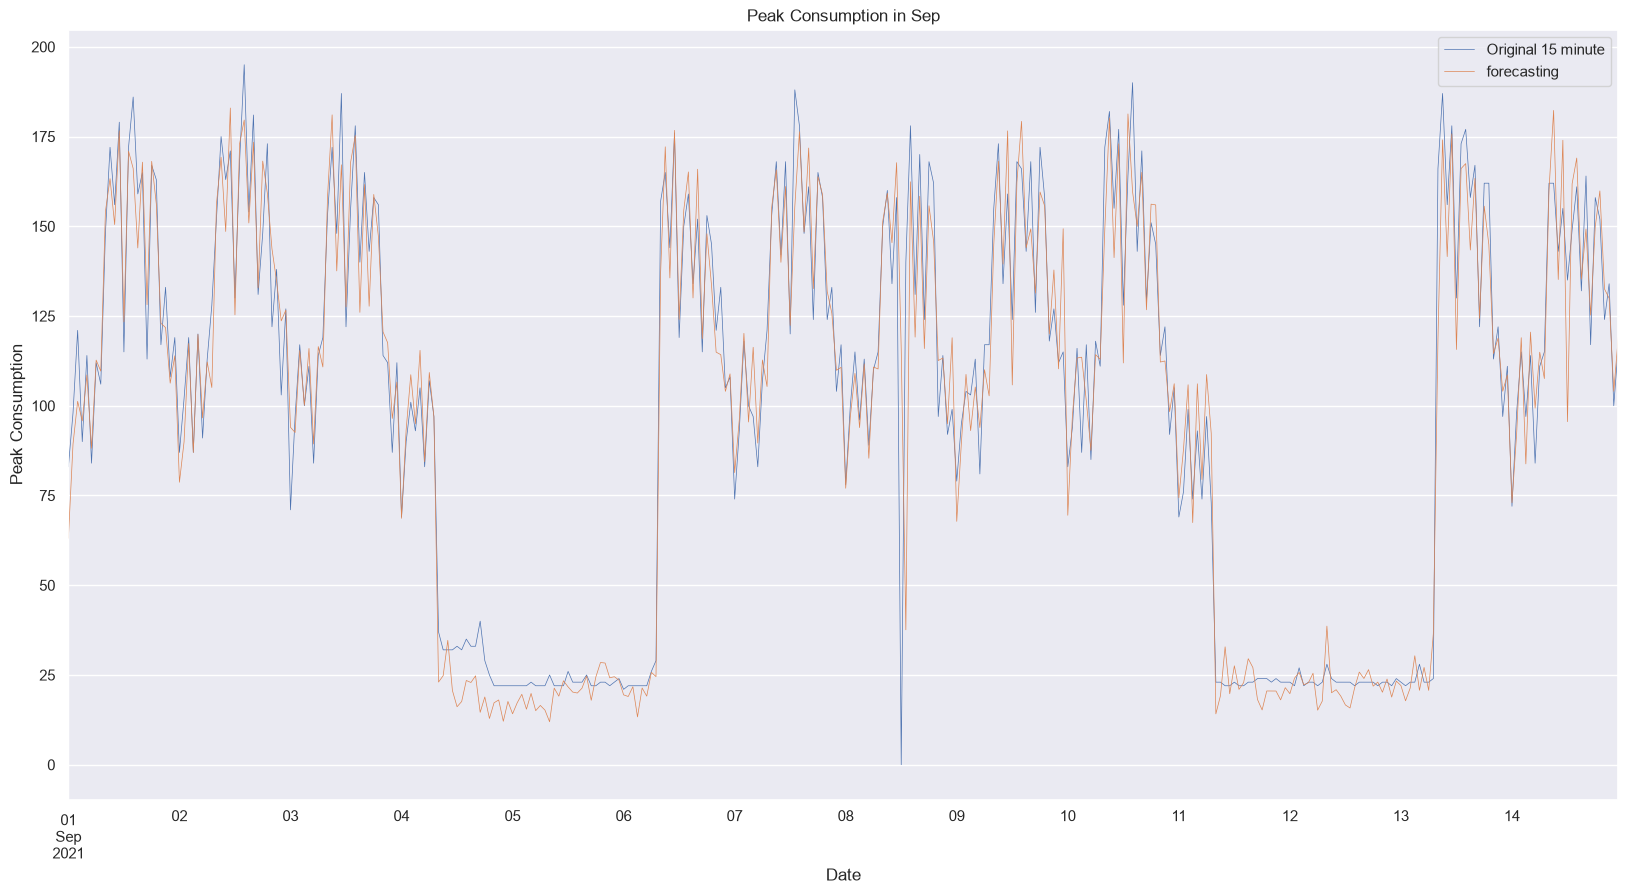

In [ ]:
compare_result.loc["2021-09"].plot(linewidth =0.5)
plt.title("Peak Consumption in Sep")
plt.ylabel("Peak Consumption")
plt.show()